In [1]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 6.2MB/s 


In [2]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import tensorflow.keras.backend
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [3]:
filename = "training_data_v2.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [4]:
b = open('GRHL1_TCCAAC20NTA_Q_3.fasta','r')
bind = b.readlines()
b.close()

u = open('GRHL1_TCCAAC20NTA_Q_3_shuffled.fasta','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [5]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [6]:
print(len(bind), len(unbind))

203209 203209


##### Reverse complement

In [7]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [8]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [9]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [10]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [11]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [12]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [13]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [14]:
x = new_df.seq
y = new_df.label

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [16]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [17]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_test = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:01:01.128523


### CNN model

In [18]:
model=Sequential()
model.add(Conv1D(filters=128, kernel_size=7, strides=1, padding='valid', activation='relu'))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='sigmoid'))

In [19]:
from keras.metrics import Precision, Recall, TruePositives
model.compile(optimizer='adam', loss="binary_crossentropy", metrics=[TruePositives(name='tp'), Precision(name='precision'), Recall(name='recall'), 'accuracy'])

In [20]:
history = model.fit(x_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
16257/16257 [==============================] - 90s 5ms/step - loss: 0.6035 - tp: 162866.5328 - precision: 0.6179 - recall: 0.6135 - accuracy: 0.6178 - val_loss: 0.5767 - val_tp: 83998.0000 - val_precision: 0.6460 - val_recall: 0.6459 - val_accuracy: 0.6459
Epoch 2/10
16257/16257 [==============================] - 86s 5ms/step - loss: 0.5725 - tp: 168031.3565 - precision: 0.6453 - recall: 0.6454 - accuracy: 0.6453 - val_loss: 0.5664 - val_tp: 84489.0000 - val_precision: 0.6497 - val_recall: 0.6496 - val_accuracy: 0.6497
Epoch 3/10
16257/16257 [==============================] - 87s 5ms/step - loss: 0.5675 - tp: 169380.1433 - precision: 0.6517 - recall: 0.6517 - accuracy: 0.6516 - val_loss: 0.5638 - val_tp: 84792.0000 - val_precision: 0.6520 - val_recall: 0.6520 - val_accuracy: 0.6520
Epoch 4/10
16257/16257 [==============================] - 87s 5ms/step - loss: 0.5642 - tp: 170410.6166 - precision: 0.6550 - recall: 0.6551 - accuracy: 0.6550 - val_loss: 0.5636 - val_tp: 85038.0

##### Evaluation

Accuracy

In [33]:
score = model.evaluate(x_test, y_t, verbose=1)
print("accuracy = " + str(round(score[4],4)))

5081/5081 [==============================] - 10s 2ms/step - loss: 0.5596 - tp: 107312.0000 - precision: 0.6601 - recall: 0.6601 - accuracy: 0.6601
accuracy = 0.6601


loss-epoch curve

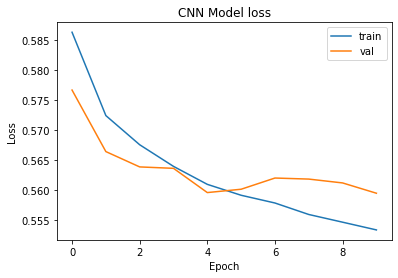

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [23]:
probs = model.predict(x_test, verbose=0)[:,1]

In [24]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

In [25]:
from sklearn.metrics import auc
pr_auc = auc(recall, precision)

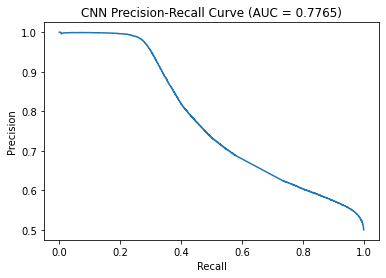

In [26]:
plt.plot(recall, precision)

plt.title('CNN Precision-Recall Curve (AUC = ' + str(round(pr_auc,4)) + ')')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC curve & AUC

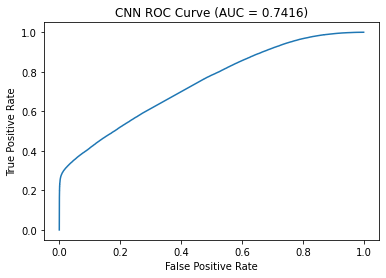

In [27]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

plt.plot(fpr, tpr)
plt.title('CNN ROC Curve (AUC = ' + str(round(auc,4)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [28]:
result_dict = {'accuracy': score[4], 'loss': history.history['loss'], 'val_loss': history.history['val_loss'],
               'precision': precision, 'recall': recall, 'tpr': tpr, 'fpr': fpr, 'auc': auc, 'pr_auc': pr_auc}
result_df = pd.DataFrame({ key:pd.Series(value) for key, value in result_dict.items() })
result_df.head()

,accuracy,loss,val_loss,precision,recall,tpr,fpr,auc,pr_auc
0,0.660105,0.586374,0.576697,0.499458,1.000000,0.000000,0.000000,0.741639,0.776506
1,NaN,0.572423,0.566397,0.499455,0.999988,0.004461,0.000000,NaN,NaN
2,NaN,0.567543,0.563832,0.499458,0.999988,0.004621,0.000000,NaN,NaN
3,NaN,0.563922,0.563595,0.499461,0.999988,0.005681,0.000012,NaN,NaN
4,NaN,0.560913,0.559536,0.499465,0.999988,0.006075,0.000025,NaN,NaN


In [29]:
result_df.to_csv ('CNN_result.csv', index = False, header=True)